<a href="https://colab.research.google.com/github/masaki-kawa/uts-study-notes/blob/main/data/raw/colab/Deep_Learning_Lab6_Exercise1_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNN with Pytorch

---

## Welcome to the sixth lab of Deep Learning!

This week, we will look at another field of Deep Learning application: Natural Language Processing (NLP).

By the end of this lab, you will be able to:
- import the relevant classes from PyTorch and Python
- build and train custom LSTM architecture for binary and multi-class classification (many-to-one)
- preprocess text data

# Binary Classification of Movie Reviews

In this exercise, we will use a sequence model (LSTM) to process reviews of movies and predict if they were positive or negative. We will be using the famous IMDB dataset. It was originally shared by Andrew L. Maas, Raymond E. Daly, Peter T. Pham, Dan Huang, Andrew Y. Ng, and Christopher Potts. It consists of movie reviews in free text form. Each review has different lengths of words and sentences.

In this exercise, you will learn to classify movie reviews as positive or negative based on the text content of the reviews.


## Objective

Our goal is to train a LSTM model with embeddings and assess its performance.

## Instructions

This is a guided exercise where some of the code have already been pre-defined. Your task is to fill the remaining part of the code (it will be highlighted with placehoders) to train and evaluate your model.

This exercise is split in several parts:
1.   Loading and Exploration of the Dataset
2.   Preparing the Dataset
3.   Defining the Architecture of the LSTM with embeddings
4.   Training and Evaluation of the Model
5.   Analysing the Results

### 1. Loading and Exploration of the Dataset

In [ ]:
!pip uninstall -y torch torchtext
!pip install torch==2.3.0 torchtext==0.18.0

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.5 MB/s eta 0:00:

**[1.1]** First we need to import the necessary libraries

In [ ]:
# Solution
import torch
import torch.nn as nn
from torchtext.data.utils import get_tokenizer
import spacy
from torchtext.vocab import build_vocab_from_iterator
from itertools import chain
from torchtext.data.functional import to_map_style_dataset
from torch.nn.utils.rnn import pad_sequence
from torchtext.vocab import Vocab
from torch.utils.data import DataLoader
import torch.optim as optim
from sklearn.model_selection import train_test_split
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import time

/usr/local/lib/python3.12/dist-packages/torchtext/data/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated

**[1.2]** Now we will choose the device type [CPU/GPU] in such a way that if GPU is available then use GPU otherwise use CPU.

In [ ]:
# Solution
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


**[1.3]** Now we will get the data directly from kaggle. To do that we need to upload `kaggle.json` file, downloaded from kaggle while being signed in by using **own account**.

How to get The Kaggle.json:

1. Sign in to your kaggle account and go to the following link `https://www.kaggle.com/settings/account`
2. Scroll down to API
3. Create new token
4. It will download a kaggle.json for you
5. upload the kaggle.json after you run the following cell.

Finally upload the `kaggle.json`

In [ ]:
# Solution
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sowilliam","key":"a393d02be31cdd553ff59f13e32a1a1a"}'}

**[1.4]** Let's connect Kaggle to Google Colab

In [ ]:
# Solution
!mkdir -p ~/.kaggle # Creates a .kaggle directory, if it does not exist. -p flag is there to make sure there is no error if the directory already exists
!cp kaggle.json ~/.kaggle/ # Copies the kaggle.json, which contains the API credentials to the .kaggle directory. this file is used to get API access.
!chmod 600 ~/.kaggle/kaggle.json  # This changes the permission to read/write for the file. This ensures security measures to protect API credentials.

**[1.5]** Now download the dataset from kaggle: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews



In [ ]:
# Solution
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
100% 25.7M/25.7M [00:03<00:00, 7.72MB/s]



**[1.5]** Now we will read the data using a `read_csv` function and save it into panda's dataframe named `data`

In [ ]:
# Solution
import pandas as pd
data = pd.read_csv('/content/imdb-dataset-of-50k-movie-reviews.zip')
print(data.head(5))

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


**[1.6]** Let's have a look at the shape of the data

In [ ]:
# Solution
print(f"Number of Rows: {data.shape[0]}")
print(f"Number of Columns: {data.shape[1]}")

Number of Rows: 50000
Number of Columns: 2


**[1.7]** To visualize the distribution of data let's use the countplot function of seaborn (https://seaborn.pydata.org/generated/seaborn.countplot.html)

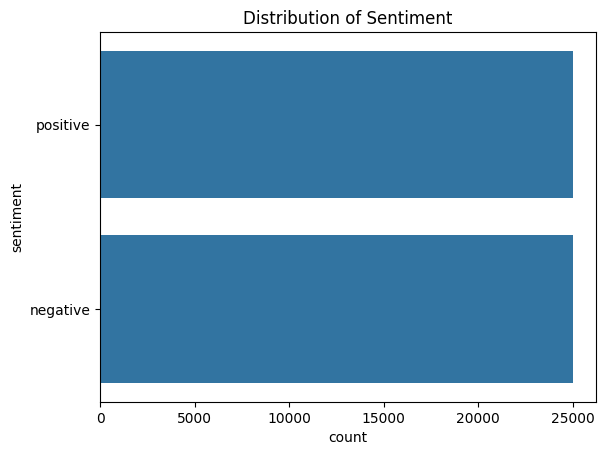

In [ ]:
# Solution
# Display distribution of sentiment
sns.countplot(data['sentiment'])
plt.title('Distribution of Sentiment')
plt.show()

### 2.   Preparing the Dataset

**[2.1]** Intially, we will split the data [review and sentiment] into features (X) and labels (y).

In [ ]:
# Solution
X = data['review' ]
y = data['sentiment']

**[2.2]** Now split the data into train-validation-test based on 60-20-20 ration

In [ ]:
# Solution
from sklearn.model_selection import train_test_split

# First split the data into training+validation set and test set
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now split the training+validation set into actual training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

**[2.3]** **Tokenization**

Loading the English tokenizer from spaCy of Python (https://spacy.io/usage/models) for tokenizing the text. Note: spaCy is a free, open-source library for advanced Natural Language Processing (NLP) in Python.


In [ ]:
# Solution
spacy_en = spacy.load('en_core_web_sm') #en_core_web_sm is a small English pipeline trained on written web text (news, comments), that includes vocabulary, syntax and entities

**[2.4]** Let's use the lambda function of Python that takes a piece of text and tokenizes it into words. Save the outcome into a variable called `tokenizer`.

In [ ]:
# Solution
tokenizer = lambda text: [tok.text for tok in spacy_en.tokenizer(text)]

**[2.5]** **Build Vocabulary**

This step creates vocabulary from the tokenized text data, which is necessary for converting words to integers. For defining the vocabulary  size explicitely, set the `max_vocab_size` = 10000.

In [ ]:
# Solution
max_vocab_size = 10000 # prevents the vocabulary from becoming too large and helps manage memory.

vocab = build_vocab_from_iterator((tokenizer(text) for text in X_train), specials=["<unk>", "<pad>"], max_tokens=max_vocab_size)
vocab.set_default_index(vocab["<unk>"])  # Handling unknown tokens

**[2.6]** Now our vocabulary is ready. Let's print the size of the vocabulary.

In [ ]:
# Solution
vocab_size = len(vocab)
print("Vocabulary size:", vocab_size)

Vocabulary size: 10000


**[2.7]** **Label encoding**

Now converts the categorical labels [for this dataset it is "positive" and "negative"] into numeric ones [`1` and `0`].

In [ ]:
# Solution
label_encoding = {'negative': 0, 'positive': 1}  # Define a simple label encoding dictionary

**[2.8]** Custom data collation function named `collate_batch(batch)`

**Task** : prepares batches of text data by tokenizing, converting to numerical indices, and padding them to a uniform length of sequences (https://pytorch.org/docs/stable/generated/torch.nn.utils.rnn.pad_sequence.html), which is necessary for batch processing in neural networks. It also encodes labels to numerical values suitable for model training. The tasks are as follows:
1. Read text and label in batch
2. Tokenize text using a predefined tokenizer
3. Convert to a list of vocabulary indices
4. Convert list of indices to a PyTorch tensor
5. Encode the label using `label_encoding`
6. Pad the text sequences using 'pad_sequence' of PyTorch (https://pytorch.org/docs/stable/generated/torch.nn.utils.rnn.pad_sequence.html)
7. Convert labels to a tensor



In [ ]:
# Solution
# Initialize a flag to control the printing
print_flag = True

def collate_batch(batch):
    global print_flag
    # Initialize lists to hold processed texts and labels
    processed_texts = []
    labels = []

    # Process each text and corresponding label in the batch
    for text, label in batch:
        # Tokenize text using a predefined tokenizer and convert to a list of vocabulary indices
        tokenized_text = tokenizer(text)
        numerical_text = [vocab[token] for token in tokenized_text]

        # Convert list of indices to a PyTorch tensor and append to the list of processed texts
        tensor_text = torch.tensor(numerical_text, dtype=torch.int64)
        processed_texts.append(tensor_text)

        # Encode the label
        encoded_label = label_encoding[label]
        labels.append(encoded_label)

        # Check if should print
        if print_flag:
            print("Sample text:", text)
            print("Tokenized text:", tokenized_text)
            print("Numerical text:", numerical_text)
            print_flag = False  # Set the flag to False after printing once

    # Pad the text sequences and convert labels to a tensor
    padded_texts = pad_sequence(processed_texts, padding_value=vocab['<pad>'], batch_first=True)
    labels_tensor = torch.tensor(labels, dtype=torch.int64)

    return padded_texts, labels_tensor

**[2.6]** Now we will call the DataLoader function that iteratively loads data based on batch size, shuffle and save it into three different variables called `train_loader`, `val_loader` and `test_loader`. Set the `BATCH_SIZE` to 32. Inside the DataLoader function we will call `collate_batch` function.

In [ ]:
# Solution
# Creating DataLoader for each dataset split
train_loader = DataLoader(list(zip(X_train, y_train)), batch_size=32, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(list(zip(X_val, y_val)), batch_size=32, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(list(zip(X_test, y_test)), batch_size=32, shuffle=False, collate_fn=collate_batch)

### 3.   Defining the Architecture of the Bi-directional LSTM with embeddings

**[3.1]** Let's create a LSTM model named `class LSTMModel`. This LSTM model processes sequences of data, applying an 1. embedding layer, 2. LSTM layer, 3. dropout and 4. fully connected layer for output predictions.

In [ ]:
# Solution
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
  """
    A Long Short-Term Memory (LSTM) network designed for sequence processing, configurable for both unidirectional
    and bidirectional data flow, making it suitable for applications that benefits from understanding both past and future context.

    Attributes:
        embedding (nn.Embedding): Embeds token indices into dense vectors of a specified size.
        lstm (nn.LSTM): Processes embedded sequence data through LSTM units, supporting both forward and backward data flows.
        dropout (nn.Dropout): Applies dropout regularization to prevent overfitting by randomly zeroing out embedding vectors.
        fc (nn.Linear): Linear layer that maps the output of the LSTM layers to the target output size, facilitating classification.

    Parameters:
        vocab_size (int): The size of the vocabulary, dictating the number of rows in the embedding matrix.
        embedding_dim (int): The dimensionality of each embedding vector.
        hidden_dim (int): The number of features in the hidden state of the LSTM.
        num_layers (int): The number of stacked LSTM layers.
        dropout (float): The dropout rate for regularization during training.
        output_dim (int): The dimensionality of the output space, corresponding to the number of output classes or features.
        bidirectional (bool): Flag to indicate whether the LSTM should process data bidirectionally.
    """
  def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, dropout, output_dim, bidirectional = True):
        super(LSTMModel, self).__init__()
        # Embedding layer initialization
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # LSTM layer initialization with optional bidirectional support and dropout
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers,
                            dropout=dropout if num_layers > 1 else 0,  # Dropout only between LSTM layers
                            batch_first=True, bidirectional=bidirectional)
        self.dropout = nn.Dropout(dropout)
        # Adjust the number of input features to the linear layer based on bidirectionality
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)

  def forward(self, text):
        # Forward pass through the embedding layer:
        # The text input is transformed into an embedded representation.
        embedded = self.embedding(text)

        # Forward pass through the LSTM:
        # Processes the embedded text. Outputs the final states and all intermediate hidden states.
        lstm_out, (hidden, cell) = self.lstm(embedded)

        # If the LSTM is bidirectional, concatenate the final forward and backward hidden states;
        # otherwise, just use the last hidden state.
        # Apply dropout to the selected hidden state to regularize.
        hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)) if self.lstm.bidirectional else self.dropout(hidden[-1,:,:])

        output = self.fc(hidden)
        return output

**[3.2]** Let's set the model parameters. Set the embedding dimension as 100, hidden dimension as 256, dropout as 0.5, set the number of epochs as 5 and output_dim 1 (since this is binary classification: positive or negative label).

In [ ]:
# Solution
vocab_size = len(vocab)  # from vocabulary build step
embedding_dim = 100
hidden_dim = 256
num_layers = 2
dropout = 0.5
num_epochs = 5
output_dim = 1  # Binary classification output

**[3.3]** Let's instantiate the newly created LSTMModel and save it to `model`. Finally send the model to available device (CPU/GPU)

In [ ]:
# Solution
# Initialize the model
model = LSTMModel(vocab_size, embedding_dim, hidden_dim, num_layers, dropout, output_dim)
model.to(device)  # Move to GPU if available

LSTMModel(
  (embedding): Embedding(10000, 100)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=1, bias=True)
)

**[3.4]** Print the model summary

In [ ]:
# Solution
# Print model summary
print(model)

LSTMModel(
  (embedding): Embedding(10000, 100)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=1, bias=True)
)


### 4.   Training and Evaluation of the Model

**[4.1]**  Instantiate a `nn.BCEWithLogitsLoss()` and save it into a variable called `criterion`. After then Instantiate a `optim.Adam()` optimizer with the model's parameters and 0.001 as learning rate and save it into a variable called `optimizer`.

In [ ]:
# Solution
# Loss function
criterion = nn.BCEWithLogitsLoss()

# Optimizer (using Adam here, but you can choose others like SGD)
optimizer = optim.Adam(model.parameters(), lr=0.001)

**[4.2]** Define the empty lists named `train_losses`, `train_accuracies`, `val_losses`, and `val_accuracies` to hold the values of accuracies and losses while training

In [ ]:
# Solution
# Lists to hold metric values for visualization and analysis
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

**[4.3]** Let's define a function called `train_model` that takes the following parameters model, device, train_loader, optimizer, criterion, device, epoch and writer for TensorBoard. This function is responsible to train our newly created LSTM model.
A nested loop is initiated that extracts data from `train_loader` and introduce the following logics:
- reset the gradients (https://pytorch.org/docs/stable/generated/torch.optim.Optimizer.zero_grad.html)
- perform the forward propagation and get the model predictions
- calculate the loss between the predictions and the actuals
- perform back propagation
- update the weights
- Count the total loss

In [ ]:
# Solution
def train_model(model, train_loader, optimizer, criterion, device, epoch, writer):
    """
    Train the model for one epoch over the training dataset.

    Args:
        model (torch.nn.Module): The neural network model to be trained.
        train_loader (torch.utils.data.DataLoader): DataLoader for the training data.
        optimizer (torch.optim.Optimizer): Optimizer used to update model weights.
        criterion (torch.nn.Module): Loss function used for training.
        device (torch.device): Device to run the training on (e.g., 'cpu' or 'cuda').
        epoch (int): Current epoch number, used for logging.
        writer (torch.utils.tensorboard.SummaryWriter): Writer object for logging to TensorBoard.

    Returns:
        float: Average loss for this epoch.
        float: Accuracy for this epoch.
    """

    # Set the model to training mode (this enables features like dropouts)
    model.train()

    # Initialize metrics
    total_loss = 0
    correct_predictions = 0
    total_samples = 0

    # Iterate over batches of data from the DataLoader
    for inputs, labels in train_loader:
        # Move data to the specified device (GPU or CPU)
        inputs, labels = inputs.to(device), labels.to(device)

        # Reset gradients (this is necessary in each step)
        optimizer.zero_grad()

        # Forward pass: compute the model output
        outputs = model(inputs)

        # Compute loss: difference between the predicted outputs and actual labels
        loss = criterion(outputs.squeeze(), labels.float())

        # Backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()

        # Perform a single optimization step (parameter update)
        optimizer.step()

        # Accumulate the training loss
        total_loss += loss.item()

        # Apply sigmoid activation to get all predictions between 0 and 1
        predicted = torch.sigmoid(outputs).round()

        # Count correct predictions
        correct_predictions += (predicted == labels.unsqueeze(1)).sum().item()

        # Update the total number of samples seen
        total_samples += labels.size(0)

    # Calculate average loss and accuracy over all training samples
    avg_loss = total_loss / len(train_loader)
    accuracy = correct_predictions / total_samples

    # Log training loss and accuracy for each epoch to TensorBoard
    writer.add_scalar('Loss/Train', avg_loss, epoch)
    writer.add_scalar('Accuracy/Train', accuracy, epoch)

    return avg_loss, accuracy

**[4.4]** To validate/evaluate the model on validation/test data, a nested loop is initiated that extracts data from `data_loader` and introduce the following logics:
- disable computing gradients (https://pytorch.org/docs/stable/generated/torch.no_grad.html)
- perform the forward propagation and get the model predictions
- calculate the loss between the predictions and the actuals
- Count the total loss
- Count the correct outcome

In [ ]:
# Solution
def evaluate_model(model, data_loader, criterion, device, writer, epoch):
    """
    Evaluate the model on a given dataset.

    Args:
        model (torch.nn.Module): The neural network model to be evaluated.
        data_loader (torch.utils.data.DataLoader): DataLoader for the dataset to be evaluated.
        criterion (torch.nn.Module): Loss function used for evaluation.
        device (torch.device): Device to run the evaluation on (e.g., 'cpu' or 'cuda').
        writer (torch.utils.tensorboard.SummaryWriter): Writer object for logging to TensorBoard.
        epoch (int): Current epoch number, used for logging.

    Returns:
        float: Average loss over the evaluated dataset.
        float: Accuracy over the evaluated dataset.
    """

    # Set model to evaluation mode. This will turn off features like Dropout.
    model.eval()

    # Disable gradient computation; gradients are not needed for evaluation, which saves memory and computation.
    with torch.no_grad():
        total_loss = 0
        correct_predictions = 0
        total_samples = 0
        predictions = []
        actuals = []

        # Iterate over all batches in the data loader
        for inputs, labels in data_loader:
            # Move data to the specified device
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass: compute the model output
            outputs = model(inputs)

            # Compute loss: evaluate the difference between output and true labels
            loss = criterion(outputs.squeeze(), labels.float())

            # Accumulate the loss over each batch
            total_loss += loss.item()

            # Convert model outputs to binary predictions.
            predicted = torch.sigmoid(outputs).round()

            # Reshape predictions to a flat array, transfer to CPU, and convert to numpy for further processing.
            predictions.extend(predicted.view(-1).cpu().numpy())
            # Similarly, process actual labels.
            actuals.extend(labels.view(-1).cpu().numpy())

            # Calculate the number of correct predictions.
            correct_predictions += (predicted == labels.unsqueeze(1)).sum().item()

            # Update total number of samples processed
            total_samples += labels.size(0)

        # Calculate average loss and accuracy over all samples
        avg_loss = total_loss / len(data_loader)
        accuracy = correct_predictions / total_samples

        # Log validation loss and accuracy for this epoch to TensorBoard
        writer.add_scalar('Validation Loss', avg_loss, epoch)
        writer.add_scalar('Validation Accuracy', accuracy, epoch)

    return avg_loss, accuracy, predictions, actuals

**[4.5]** Set up TensorBoard for logging and visualizing the neural network training process.

In [ ]:
# Solution
from torch.utils.tensorboard import SummaryWriter

# Purpose: Set up TensorBoard for logging and visualizing the neural network training process.
# This allows for effective monitoring and analysis of the model performance over time, aiding in debugging and optimization.

# Initialize the TensorBoard writer:
# The 'SummaryWriter' object is responsible for writing data to a directory ('runs/imdb_classification') that TensorBoard will read from.
writer = SummaryWriter('runs/imdb_classification')

# Explanation:
# - 'SummaryWriter' is a class from the 'torch.utils.tensorboard' package.
# - The directory specified ('runs/imdb_classification') is where all logs will be saved. This directory structure is useful for organizing multiple experiments.
# - TensorBoard will access this directory to display metrics such as loss and accuracy, along with other visualizable data, helping to track the model's training and validation progress over epochs.

**[4.6]** **Training:** Now it is time to train our model by calling `train_model` and `evaluate_model` functions that introduced previously. The evaluation metrics are stored in train_losses, val_losses, train_accuracies, val_accuracies by using append function.

In [ ]:
# Solution
import time  # Importing the time module to track the duration of each epoch

# Loop through each epoch to train and validate the model
for epoch in range(num_epochs):
    # Record the start time of the epoch to calculate the duration later
    start_time = time.time()

    # Train the model using the train_loader
    # train_model function returns the average loss and accuracy for this training epoch
    train_loss, train_accuracy = train_model(model, train_loader, optimizer, criterion, device, epoch, writer)

    # Evaluate the model using the val_loader
    # evaluate_model function returns the average loss and accuracy for this validation epoch
    val_loss, val_accuracy, _, _ = evaluate_model(model, val_loader, criterion, device, writer, epoch)

    # Store metrics for later analysis and visualization in TensorBoard
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # Record the end time of the epoch and calculate the duration
    end_time = time.time()
    epoch_duration = end_time - start_time

    # Print a detailed summary of the epoch's results to the console
    print('*' * 50)
    print(f'Epoch: {epoch + 1}')
    print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')
    print(f'Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')
    print(f'Epoch Duration: {epoch_duration:.2f} seconds')  # Duration of the epoch in seconds
    print('*' * 50)

Sample text: You may want to know up front that I am not a Mormon, unlike a good number of those who have already reviewed this film. I mention this so you'll understand that the way I look at the film may differ greatly from those in the faith. For some, being critical of the film might be seen as being critical of the faith--and that is NOT my intention. So, my review is that of an outsider trying to look inside and learn more about who this man and his people were. Well, after seeing the film, I doubt if I have learned much at all. Since I have been a history teacher, I have a good basic understanding about Young as well as Joseph Smith as well as the teachings of the church. But anyone wanting to see this film to really learn anything will probably be disappointed because the film seems so gosh-darn nice--too nice and too unrealistic in its portrayal. Plus, you learn practically nothing about the church's beliefs other than they are nice people, work hard and some have many wives (

**[4.7]** **Testing:** Now it is time to test our model. In this case we could call the `evaluate_model` function (since it is designed in such a way that it could work for test function as well) by sending the following parameters 1. model, 2. device, 3. test_loader and 4. criterion, 5. writer and 6. epoch.Evaludate the model on test dataset

In [ ]:
# Solution
test_loss, test_accuracy, test_predictions, test_actuals = evaluate_model(model, test_loader, criterion, device, writer, epoch)

**[4.8]** Let's print the `test_accuracy` and `test_loss`.

In [ ]:
# Solution
print(f"Accuracy on test split: {test_accuracy}")
print(f"loss on test split: {test_loss}")

Accuracy on test split: 0.893
loss on test split: 0.25985292415506545


### 5. Analysing the results

**[5.1]** Load tensorboard to visualize the training and validation

In [ ]:
# Solution
%load_ext tensorboard
%tensorboard --logdir runs

**[5.2]** Let's plot the training and validation losses

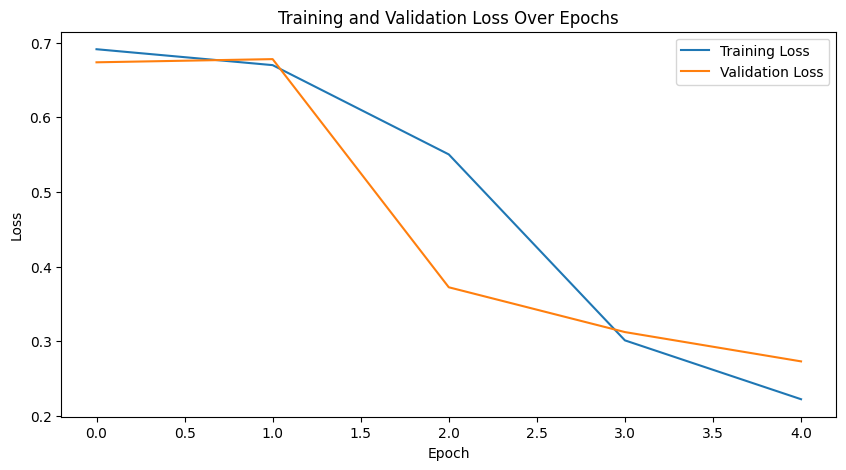

In [ ]:
# Solution
# Plotting the training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

**[5.3]** Let's plot the training and validation accuracies

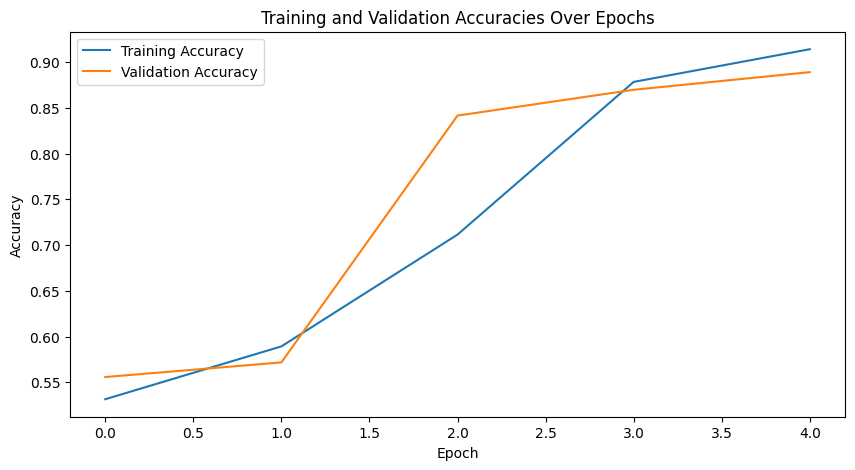

In [ ]:
# Solution
# Plotting the training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracies Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**[5.4]** Display the confusion matrix

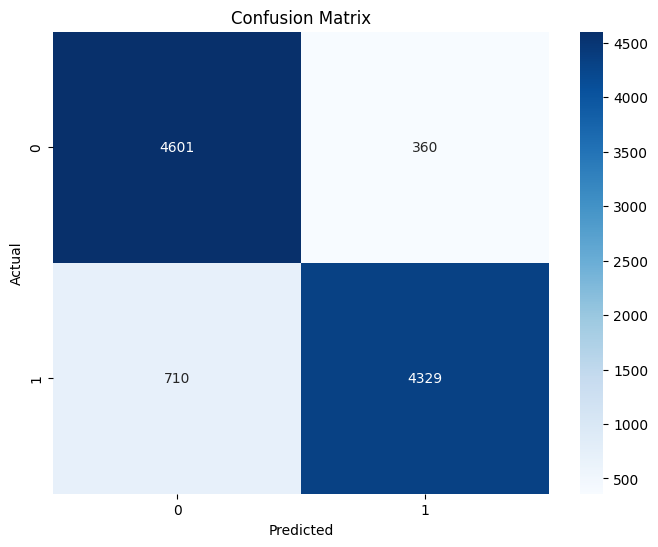

In [ ]:
# Solution
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_actuals, test_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()